## 🎓 Student Dropout Batch Predictions
This notebook performs **batch inference** using the latest Champion model (`StudentDropout_Logistic_FirstSemester`) registered in MLflow.  
Predictions are written to a Delta table for downstream analysis or dashboards.

---


In [0]:
import pandas as pd
import numpy as np
import mlflow
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

# Set plotting style
sns.set(style="whitegrid")


mlflow.end_run()  # Ends any active run

#### Load MLflow Champion Model
We load the latest **Champion** model version for first semester features.

In [0]:
with mlflow.start_run(run_name="Batch_Inference_FirstSemester") as run:

    model_name = "StudentDropout_Logistic_FirstSemester"
    model = mlflow.pyfunc.load_model(f"models:/{model_name}@Champion")
    
    # Log the model used
    mlflow.set_tag("model_used", model_name)

2026/03/23 19:23:27 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - mlflow (current: 3.8.1, required: mlflow==2.22.0)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.


#### Load Data from Delta
We load the raw student dataset and prepare the features used by the model.

In [0]:
import pandas as pd
import mlflow
from mlflow.types import DataType
# Load Delta table
spark_df = spark.table("workspace.default.student_dropout_raw")
df = spark_df.toPandas()

# Define feature set used by the first semester model
first_sem_cols = [col for col in df.columns if not col.startswith("curricular_units_2nd_sem") and col != "target"]
X = df[first_sem_cols]

# Map MLflow DataTypes to Python types
mlflow_to_pytype = {
    DataType.double: "float64",
    DataType.float: "float32",
    DataType.integer: "int64",
    DataType.long: "int64",
    DataType.string: "object",
    DataType.boolean: "bool"
}

# Get model input schema
input_schema = model.metadata.get_input_schema()

# Cast columns to expected types
for col in input_schema.inputs:
    dtype = mlflow_to_pytype.get(col.type, "object")  # default to object
    if col.name in X.columns:
        X[col.name] = X[col.name].astype(dtype)


# Log number of rows and features
mlflow.log_param("num_rows", len(df))
mlflow.log_param("num_features", len(first_sem_cols))

/home/spark-44c6d33f-4cf3-4f18-92b3-f8/.ipykernel/2777/command-8583435182204133-1065643231:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col.name] = X[col.name].astype(dtype)
/home/spark-44c6d33f-4cf3-4f18-92b3-f8/.ipykernel/2777/command-8583435182204133-1065643231:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col.name] = X[col.name].astype(dtype)
/home/spark-44c6d33f-4cf3-4f18-92b3-f8/.ipykernel/2777/command-8583435182204133-1065643231:29: SettingWithCopyWarning: 
A value is trying to be set on

30

#### Run Predictions
Apply the model to the dataset and store predictions in a new column.

In [0]:

# Now generate predictions
preds = model.predict(X)
df["prediction"] = preds

# Optional: log sample predictions
mlflow.log_text("\n".join(map(str, preds[:10])), "sample_predictions.txt")
mlflow.log_param("num_predictions", len(preds))

4424

In [0]:
preds = model.predict(X)
df["prediction"] = preds

# Optional: log a small sample of predictions
mlflow.log_text("\n".join(map(str, preds[:10])), "sample_predictions.txt")
mlflow.log_param("num_predictions", len(preds))

4424

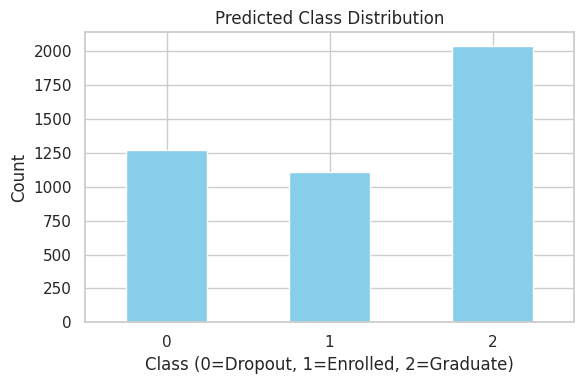

In [0]:
# Distribution of predicted classes
plt.figure(figsize=(6,4))
pd.Series(preds).value_counts().sort_index().plot(kind="bar", color="skyblue")
plt.title("Predicted Class Distribution")
plt.xlabel("Class (0=Dropout, 1=Enrolled, 2=Graduate)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Log distribution as metrics
for cls, count in pd.Series(preds).value_counts().items():
    mlflow.log_metric(f"class_{cls}_count", count)

#### Save Predictions to Delta
We write the results back to a Delta table for downstream use.

In [0]:
from pyspark.sql.types import DoubleType, LongType, IntegerType, StringType, TimestampType

# Add a timestamp column for reproducibility
df["inference_timestamp"] = datetime.now()

existing_schema = spark.table("workspace.default.student_dropout_predictions").schema


# Mapping Spark types to Pandas/NumPy types
type_map = {
    DoubleType: "float64",
    LongType: "int64",
    IntegerType: "int32",
    StringType: "object",
    TimestampType: "datetime64[ns]"
}

# Cast df columns to match existing table schema
for field in existing_schema:
    if field.name in df.columns:
        spark_type = type(field.dataType)
        if spark_type in type_map:
            df[field.name] = df[field.name].astype(type_map[spark_type])
        else:
            print(f"Warning: no mapping for {field.name} of type {field.dataType}")
# Convert to Spark DataFrame
spark_pred_df = spark.createDataFrame(df)

# Overwrite table
spark_pred_df.write \
    .mode("overwrite") \
    .option("mergeSchema", "true") \
    .saveAsTable("workspace.default.student_dropout_predictions")

#### ✅ Key Notes
- Uses MLflow Champion model for reproducibility.
- Logs batch run parameters, prediction sample, and class distribution metrics.
- Saves results to Delta with timestamps for historical tracking.
- Can be scheduled as a **Databricks Job** for periodic inference.